In [46]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import pandas as pd

# Matplotlib: Figure vs Axes

Antes de construir gráficos mais elaborados, é importante compreender dois conceitos fundamentais do Matplotlib: *Figure* e *Axes*.

## Figure
A **Figure** é o objeto que representa o contentor global da visualização. Corresponde à área total onde os gráficos serão desenhados.

Pode ser interpretada como a "tela" onde todos os elementos gráficos são organizados.

---

## Axes
Os **Axes** são as regiões dentro da Figure onde os dados são efetivamente representados.

Cada Axes corresponde a um gráfico individual e inclui:
- eixo horizontal (x)
- eixo vertical (y)
- elementos gráficos (linhas, pontos, barras, etc.)

---

## Relação entre Figure e Axes

Uma Figure pode conter:
- um único Axes (caso mais simples)
- múltiplos Axes (subplots)

Estrutura conceptual:


In [2]:
# Figure
#  └── Axes
#       ├── eixo X
#       ├── eixo Y
#       └── dados


## Exemplo Prático

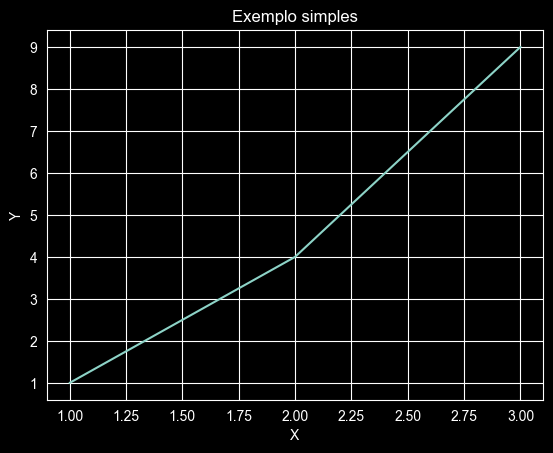

In [3]:
# criar Figure e Axes
fig, ax = plt.subplots()

#cria os valores de x e y
plt.plot([1, 2, 3], [1, 4, 9])

#muda coisas do grafico como titulo e descricao dos eixos
plt.title("Exemplo simples")
plt.xlabel("X")
plt.ylabel("Y")

#renderizar o grafico
plt.show()

- Para o exemplo acima os dados de x e y foram adicionados em forma de lista, mas também é possível usar arrays do NumPy ou colunas de um DataFrame do Pandas.
- A parte de personalização do gráfico é feita através dos métodos do objeto Axes, como `set_title()`, `set_xlabel()`, e `set_ylabel()`, que permitem adicionar títulos e rótulos aos eixos.

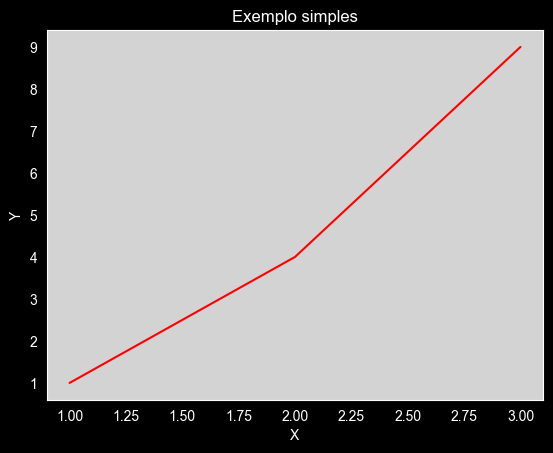

In [4]:
# criar Figure e Axes
fig, ax = plt.subplots()

# gráfico com linha vermelha
ax.plot([1, 2, 3], [1, 4, 9], color='red')

# remover grid
ax.grid(False)

# alterar fundo do gráfico (Axes)
ax.set_facecolor('lightgray')

# título e labels
ax.set_title("Exemplo simples")
ax.set_xlabel("X")
ax.set_ylabel("Y")

# renderizar
plt.show()

Evoluindo um pouco mais.

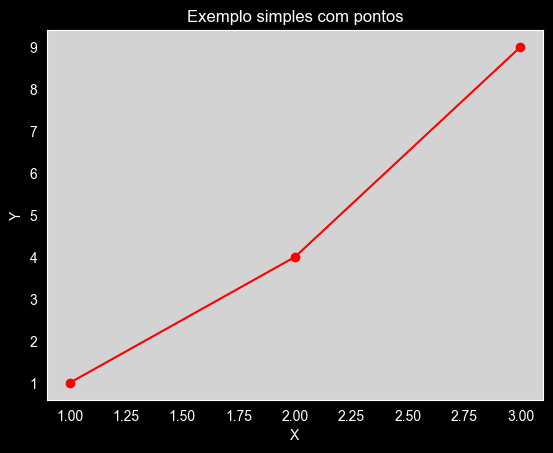

In [5]:
# criar Figure e Axes
fig, ax = plt.subplots()

# gráfico com linha vermelha e pontos
ax.plot(
    [1, 2, 3],
    [1, 4, 9],
    color='red',
    marker='o'   # adiciona pontos
)

# remover grid
ax.grid(False)

# fundo cinza
ax.set_facecolor('lightgray')

# título e labels
ax.set_title("Exemplo simples com pontos")
ax.set_xlabel("X")
ax.set_ylabel("Y")

# renderizar
plt.show()

Agora com duas linhas:

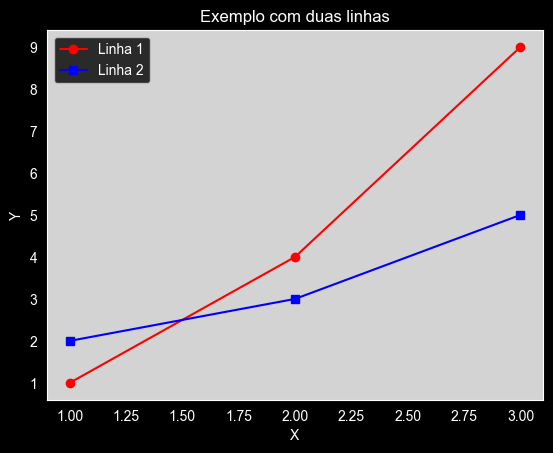

In [6]:
# criar Figure e Axes
fig, ax = plt.subplots()

# primeira linha
ax.plot(
    [1, 2, 3],
    [1, 4, 9],
    color='red',
    marker='o',
    label='Linha 1'
)

# segunda linha
ax.plot(
    [1, 2, 3],
    [2, 3, 5],
    color='blue',
    marker='s',
    label='Linha 2'
)

# remover grid
ax.grid(False)

# fundo cinza
ax.set_facecolor('lightgray')

# título e labels
ax.set_title("Exemplo com duas linhas")
ax.set_xlabel("X")
ax.set_ylabel("Y")

# legenda
ax.legend()

# renderizar
plt.show()

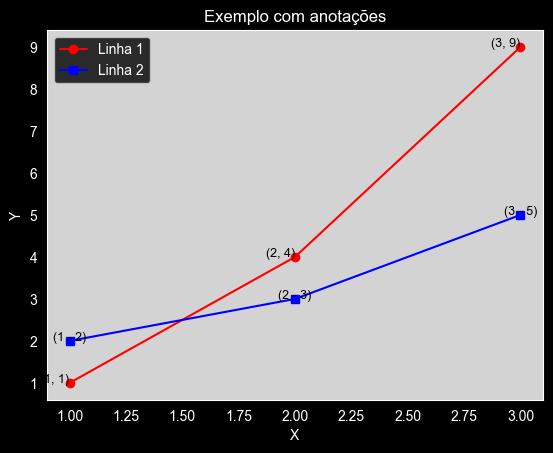

In [7]:
# dados
x = [1, 2, 3]
y1 = [1, 4, 9]
y2 = [2, 3, 5]

# criar Figure e Axes
fig, ax = plt.subplots()

# primeira linha
ax.plot(x, y1, color='red', marker='o', label='Linha 1')

# segunda linha
ax.plot(x, y2, color='blue', marker='s', label='Linha 2')

# adicionar valores nos pontos (linha 1)
for xi, yi in zip(x, y1):
    ax.text(xi, yi, f"({xi}, {yi})", fontsize=9, ha='right', color='black')
    #(valor de x, valor de y, formato em que quero que apareça o string e mudança das caracteristicas

# adicionar valores nos pontos (linha 2)
for xi, yi in zip(x, y2):
    ax.text(xi, yi, f"({xi} - {yi})", fontsize=9, ha='center', color='black')

# remover grid
ax.grid(False)

# fundo cinza
ax.set_facecolor('lightgray')

# título e labels
ax.set_title("Exemplo com anotações")
ax.set_xlabel("X")
ax.set_ylabel("Y")

# legenda
ax.legend()

plt.show()

Uma linha em cima da outra pode ser confuso e entao vamos criar subplots para separar as linhas em gráficos diferentes.

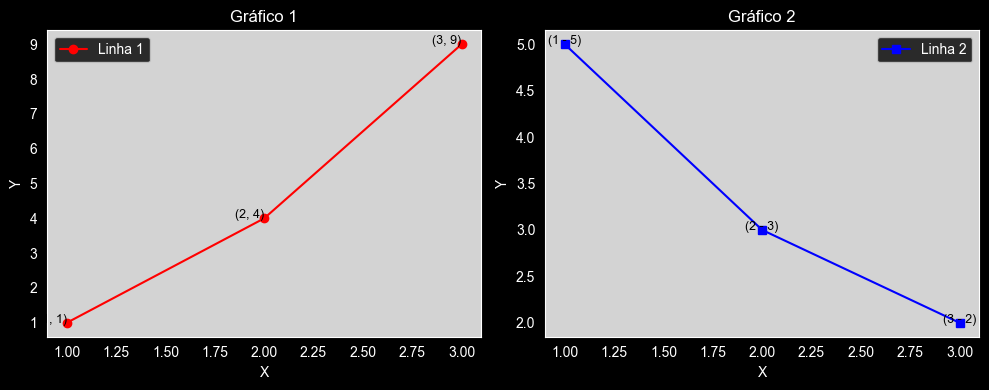

In [8]:
# dados
x = [1, 2, 3]
y1 = [1, 4, 9]
y2 = [5, 3, 2]

# criar Figure e múltiplos Axes (1 linha, 2 colunas)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))


# gráfico 1 (linha 1)
axes[0].plot(x, y1, color='red', marker='o', label='Linha 1')
#passado aqui o parametro axes para indicar que o esse grafico fica no primeiro subplot (coluna 1)
#daqui pra frente sempre usa o axes0 e so muda quando for criar o segundo grafico

for xi, yi in zip(x, y1):
    axes[0].text(xi, yi, f"({xi}, {yi})", fontsize=9, ha='right', color='black')

axes[0].set_title("Gráfico 1")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")
axes[0].set_facecolor('lightgray')
axes[0].grid(False)
axes[0].legend()


# gráfico 2 (linha 2)
axes[1].plot(x, y2, color='blue', marker='s', label='Linha 2')

for xi, yi in zip(x, y2):
    axes[1].text(xi, yi, f"({xi} - {yi})", fontsize=9, ha='center', color='black')

axes[1].set_title("Gráfico 2")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")
axes[1].set_facecolor('lightgray')
axes[1].grid(False)
axes[1].legend()

# ajustar layout
plt.tight_layout() # usamos para ajustar os graficos na visualizacao.

plt.show()

# Histograma

O histograma é utilizado para visualizar a distribuição de uma variável numérica.

Este tipo de gráfico agrupa os valores em intervalos (*bins*) e mostra a frequência de observações em cada intervalo.

---

## Quando utilizar

- Analisar distribuição de dados
- Identificar assimetrias (skewness)
- Detetar outliers
- Verificar concentração de valores

---

## Conceitos importantes

- **Bins**: intervalos que agrupam os dados
- **Frequência**: número de observações em cada bin

---

Vamos começar com um exemplo simples utilizando Matplotlib.

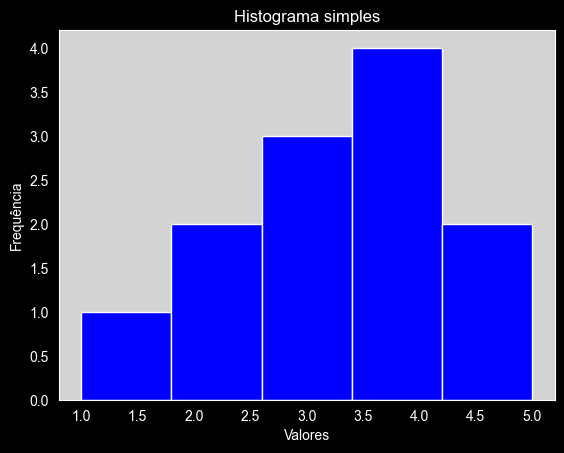

In [9]:
# dados simples
#os dados de entrada nao sao mais x e y mas sim uma lista de valores (com valores repitidos para ele somar
valores = [1, 2, 2, 3, 3, 3, 4, 4, 4, 4, 5, 5]

# criar figure e axes
fig, ax = plt.subplots()

# histograma (tipo .hist)
ax.hist(valores, bins=5, color='blue')
#bins representam quantos bins totais terá o grafico e o seu range.

# título e labels
ax.set_title("Histograma simples")
ax.set_xlabel("Valores")
ax.set_ylabel("Frequência")

# remover grid
ax.grid(False)

# fundo
ax.set_facecolor('lightgray')

plt.show()

Experimentando diferentes valores de bins:

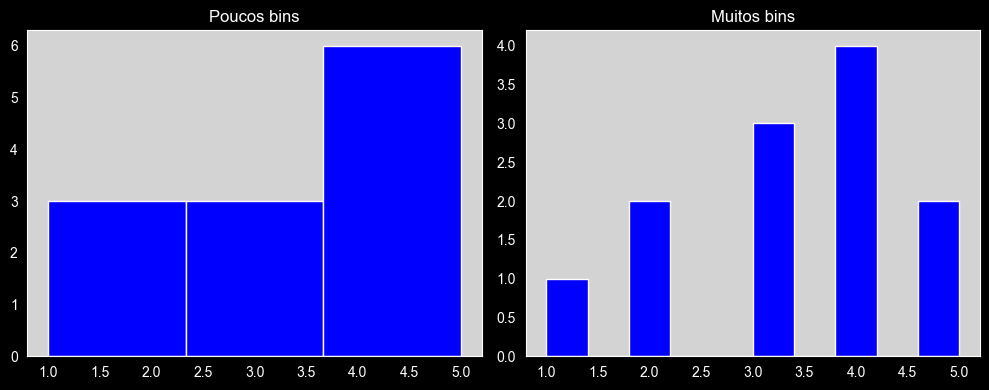

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# poucos bins
axes[0].hist(valores, bins=3, color='blue')
axes[0].set_title("Poucos bins")

# muitos bins
axes[1].hist(valores, bins=10, color='blue')
axes[1].set_title("Muitos bins")

for ax in axes:
    ax.set_facecolor('lightgray')
    ax.grid(False)

plt.tight_layout()
plt.show()

Criando um boxplot sobre a distribuição acima:

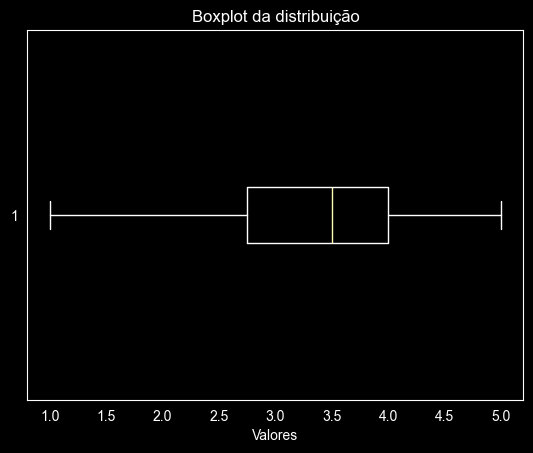

In [11]:
# dados
valores = [1, 2, 2, 3, 3, 3, 4, 4, 4, 4, 5, 5]

# criar figure e axes
fig, ax = plt.subplots()

# boxplot horizontal
ax.boxplot(valores, vert=False)

# título e labels
ax.set_title("Boxplot da distribuição")
ax.set_xlabel("Valores")

# remover grid
ax.grid(False)

# fundo
# ax.set_facecolor('lightgray')

plt.show()

Criando uma visualizacao combinada de histograma e boxplot:

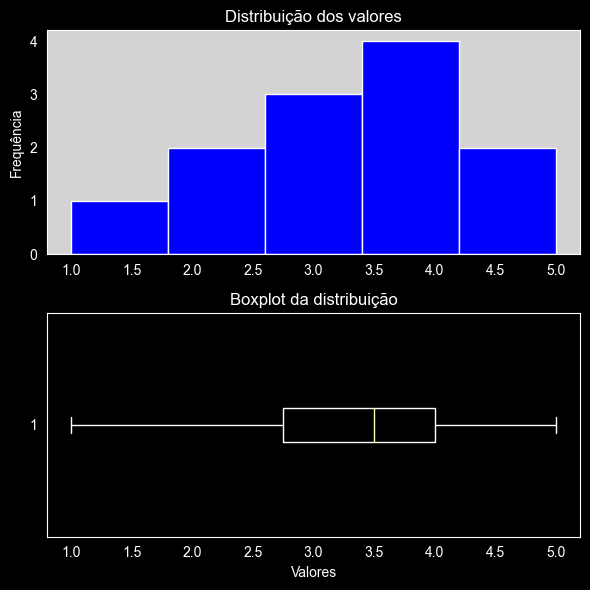

In [12]:
# dados
valores = [1, 2, 2, 3, 3, 3, 4, 4, 4, 4, 5, 5]
#forçar entrar um outlier para ver o impacto

# criar Figure e Axes (2 linhas, 1 coluna)
fig, axes = plt.subplots(2, 1, figsize=(6, 6))

# histograma (topo)
axes[0].hist(valores, bins=5, color='blue')
axes[0].set_title("Distribuição dos valores")
axes[0].set_ylabel("Frequência")
axes[0].set_facecolor('lightgray')
axes[0].grid(False)

# boxplot (baixo)
axes[1].boxplot(valores, vert=False)
axes[1].set_title("Boxplot da distribuição")
axes[1].set_xlabel("Valores")
# axes[1].set_facecolor('lightgray')
axes[1].grid(False)

# ajustar layout
plt.tight_layout()

plt.show()

## Combinação de gráficos: barras e linhas

É possível representar diferentes tipos de informação no mesmo gráfico, combinando múltiplos formatos.

Neste exemplo:
- gráfico de barras → valores individuais
- gráfico de linha → tendência dos valores

---

## Vantagens

- Permite comparar valores e tendência simultaneamente
- Facilita a leitura de padrões
- Muito utilizado em análise exploratória

---

Ambos os gráficos são desenhados no mesmo Axes.

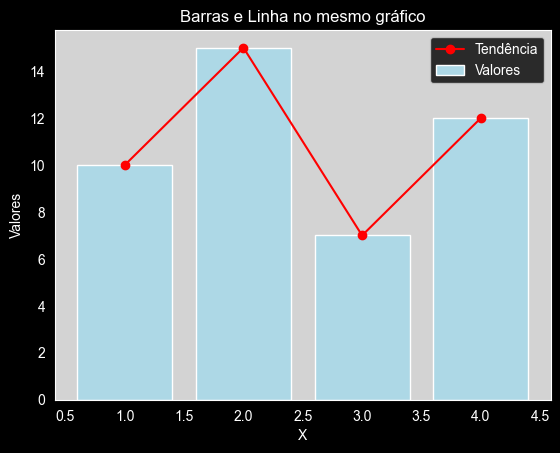

In [13]:
# dados
x = [1, 2, 3, 4]
valores = [10, 15, 7, 12]

# criar figure e axes
fig, ax = plt.subplots()

# gráfico de barras
ax.bar(x, valores, color='lightblue', label='Valores')

# gráfico de linha (sobreposto)
ax.plot(x, valores, color='red', marker='o', label='Tendência')

# definir limite do eixo Y
# ax.set_ylim(0, 20)

# título e labels
ax.set_title("Barras e Linha no mesmo gráfico")
ax.set_xlabel("X")
ax.set_ylabel("Valores")

# remover grid
ax.grid(False)

# fundo
ax.set_facecolor('lightgray')

# legenda
ax.legend()

plt.show()

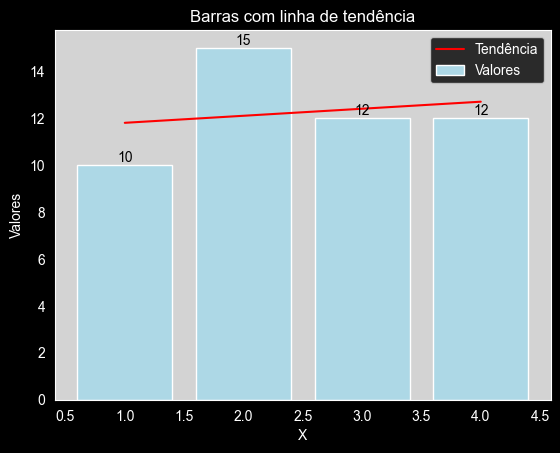

In [14]:
# dados
x = np.array([1, 2, 3, 4])
valores = np.array([10, 15, 12, 12])

# criar figure e axes
fig, ax = plt.subplots()

# gráfico de barras (guardar referência)
barras = ax.bar(x, valores, color='lightblue', label='Valores')

# adicionar valores nas barras
ax.bar_label(barras,color = 'black')

# calcular linha de tendência
coef = np.polyfit(x, valores, 1)
tendencia = np.poly1d(coef) # é um modelo
x_linha = np.linspace(min(x), max(x), 100)
y_linha = tendencia(x_linha)
# plot da tendência
ax.plot(x_linha, y_linha, color='red', label='Tendência')

# título e labels
ax.set_title("Barras com linha de tendência")
ax.set_xlabel("X")
ax.set_ylabel("Valores")

# remover grid
ax.grid(False)

# fundo
ax.set_facecolor('lightgray')

# legenda
ax.legend()

plt.show()

# Introdução ao Seaborn

Até agora, utilizámos o Matplotlib para construir visualizações de forma explícita e detalhada.

Essa abordagem permitiu:
- compreender os elementos fundamentais de um gráfico (Figure, Axes)
- controlar cada componente individualmente
- construir visualizações passo a passo

No entanto, esta flexibilidade vem com um custo:
- mais código
- maior complexidade
- necessidade de gerir manualmente vários detalhes

---

## Transição para uma abordagem mais especializada

Nesta secção, introduzimos o Seaborn, uma biblioteca construída sobre o Matplotlib, mas focada especificamente em visualização de dados.

O Seaborn oferece:
- funções de alto nível para gráficos estatísticos
- integração direta com DataFrames
- melhores configurações visuais por defeito
- menor quantidade de código para produzir gráficos informativos

---

## Mudança de paradigma

Com o Matplotlib:
- construímos gráficos manualmente
- controlamos cada elemento individual

Com o Seaborn:
- descrevemos o tipo de visualização pretendida
- a biblioteca trata automaticamente da construção do gráfico

---

## Objetivo

O objetivo não é substituir o Matplotlib, mas sim complementar:

- Matplotlib → controlo e flexibilidade
- Seaborn → rapidez e expressividade

---

Ao longo desta secção, iremos reutilizar conceitos já abordados e mostrar como o Seaborn permite produzir visualizações mais complexas de forma mais eficiente.

In [15]:
# dados
dados = np.random.normal(loc=0, scale=1, size=1000)

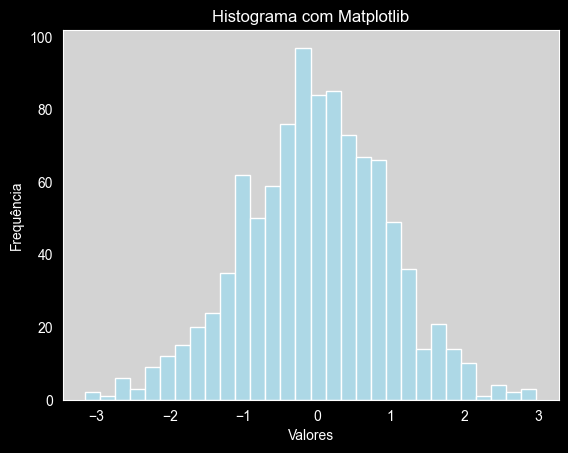

In [16]:
# criar figure e axes
fig, ax = plt.subplots()

# histograma
ax.hist(dados, bins=30, color='lightblue')

# estilo consistente
ax.set_facecolor('lightgray')
ax.grid(False)

# título e labels
ax.set_title("Histograma com Matplotlib")
ax.set_xlabel("Valores")
ax.set_ylabel("Frequência")

plt.show()

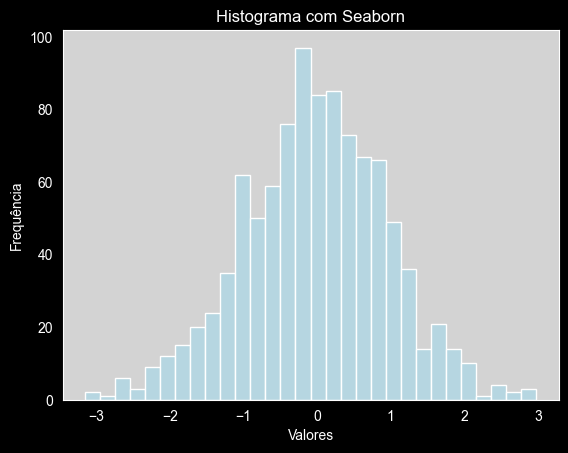

In [17]:
# criar figure e axes
fig, ax = plt.subplots()

# histograma
sns.histplot(dados, bins=30, color='lightblue', ax=ax)

# forçar mesma estética
ax.set_facecolor('lightgray')
ax.grid(False)

# título e labels
ax.set_title("Histograma com Seaborn")
ax.set_xlabel("Valores")
ax.set_ylabel("Frequência")

plt.show()

## Quando vale a pena usar Seaborn?

Nos exemplos anteriores, os resultados com Matplotlib e Seaborn são muito semelhantes.

Isto levanta uma questão importante:

> Se o resultado é o mesmo, qual a vantagem do Seaborn?

---

## Resposta

Para gráficos simples, a diferença é reduzida.

No entanto, o Seaborn torna-se especialmente útil quando:

- trabalhamos com DataFrames
- queremos comparar grupos
- precisamos de múltiplas dimensões no mesmo gráfico
- queremos adicionar informação estatística automaticamente

---

## Exemplo de ganho imediato

Com Seaborn, é possível fazer isto:

    sns.histplot(data=df, x="age", hue="sex")

Com uma única linha:
- separa por categorias
- aplica cores automaticamente
- gera legenda

---

## Com Matplotlib

O mesmo gráfico exigiria:
- filtrar dados manualmente
- fazer vários plots
- gerir cores e legenda

---

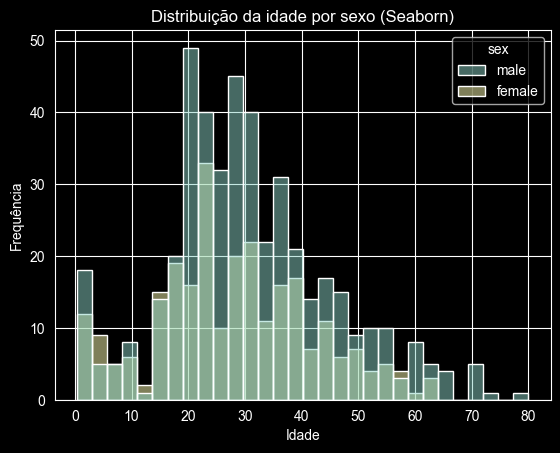

In [18]:
# carregar dataset
df = sns.load_dataset("titanic")

# criar figure
fig, ax = plt.subplots()

# histograma com separação por categoria
sns.histplot(data=df, x="age", hue="sex", bins=30, ax=ax)
#hue é uma dimensão de categorização, ou seja, ele vai separar os dados por sexo e colocar uma cor diferente para cada categoria (masculino e feminino)

# título e labels
ax.set_title("Distribuição da idade por sexo (Seaborn)")
ax.set_xlabel("Idade")
ax.set_ylabel("Frequência")

plt.show()

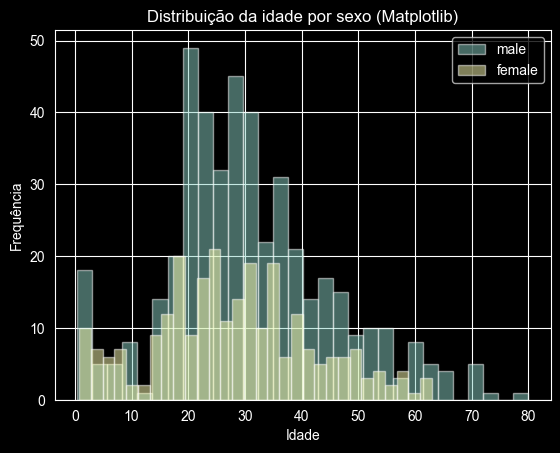

In [19]:
# separar dados manualmente
age_male = df[df["sex"] == "male"]["age"].dropna()
age_female = df[df["sex"] == "female"]["age"].dropna()

# criar figure
fig, ax = plt.subplots()

# histogramas separados
ax.hist(age_male, bins=30, alpha=0.5, label="male")
ax.hist(age_female, bins=30, alpha=0.5, label="female")

# título e labels
ax.set_title("Distribuição da idade por sexo (Matplotlib)")
ax.set_xlabel("Idade")
ax.set_ylabel("Frequência")

# legenda
ax.legend()

plt.show()

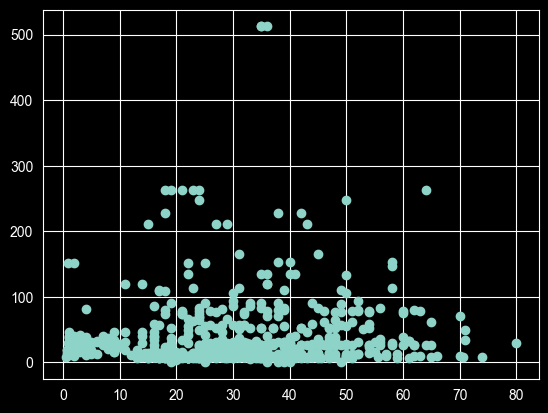

In [20]:
# Matplotlib (com pandas)
plt.scatter(df["age"], df["fare"])

<Axes: xlabel='age', ylabel='fare'>

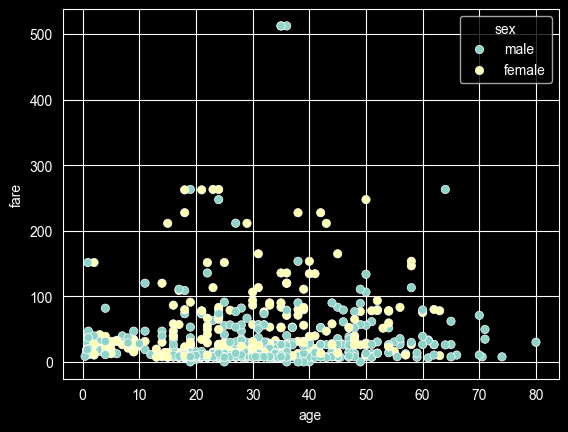

In [21]:
# Seaborn
sns.scatterplot(data=df, x="age", y="fare", hue="sex")

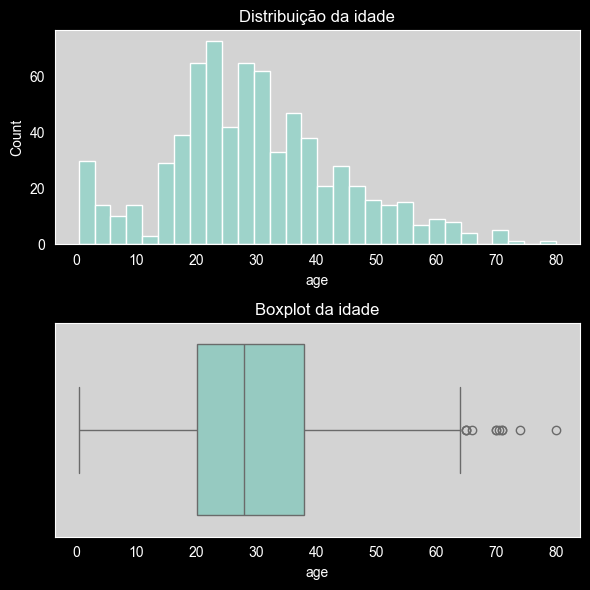

In [22]:
# criar subplots
fig, axes = plt.subplots(2, 1, figsize=(6, 6))

# histograma (topo)
sns.histplot(data=df, x="age", bins=30, ax=axes[0])
axes[0].set_title("Distribuição da idade")
axes[0].set_facecolor('lightgray')
axes[0].grid(False)

# boxplot (baixo)
sns.boxplot(data=df, x="age", ax=axes[1])
axes[1].set_title("Boxplot da idade")
axes[1].set_facecolor('lightgray')
axes[1].grid(False)

plt.tight_layout()
plt.show()

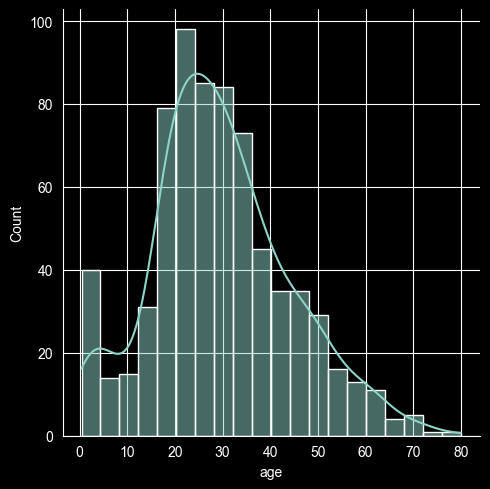

In [23]:
sns.displot(data=df, x="age", kind="hist", kde=True)
#no caso o displot é uma função de alto nível do Seaborn que cria um gráfico de distribuição. O parâmetro `kind="hist"` indica que queremos um histograma, e `kde=True` adiciona uma curva de densidade ao gráfico, mostrando a forma da distribuição dos dados de idade. O resultado é um gráfico que combina o histograma com a curva de densidade, facilitando a visualização da distribuição dos dados.

## Introdução ao Plotly

Até agora utilizámos:

- Matplotlib → controlo e construção manual
- Seaborn → abstração e análise estatística

O Plotly introduz uma nova dimensão:

- visualizações interativas

---

## O que distingue o Plotly?

Com o Plotly é possível:

- fazer zoom nos gráficos
- passar o rato para ver valores (hover)
- esconder/mostrar séries
- explorar dados dinamicamente

---

## Mudança de paradigma

- Matplotlib / Seaborn → gráficos estáticos
- Plotly → gráficos interativos

---

## Quando usar Plotly?

- dashboards
- exploração interativa
- apresentações
- aplicações web

---

## Nota

O Plotly também trabalha diretamente com DataFrames, tal como o Seaborn, mas com foco em interatividade.

In [24]:
# carregar dataset
df = sns.load_dataset("titanic")

# histograma
fig = px.histogram(df, x="age", color="sex", nbins=30)

fig.show()

In [25]:
#mudar a paleta de cores
fig = px.histogram(df, x="age", color="sex", nbins=30, color_discrete_sequence=["lightblue", "lightpink"])
fig.show()
#intuitivamente o que aparece no hover?
#o que é um hover?

Scatterplot interativo com Plotly:

In [26]:
#load dataset
df = px.data.gapminder()
df.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


In [27]:
fig = px.scatter(
    df.query("year == 2007"),
    x="gdpPercap",
    y="lifeExp",
    size="pop",
    color="continent",
    hover_name="country",
    log_x=True
)

fig.show()

In [28]:
fig = px.scatter(
    df.query("year == 2007"),
    x="gdpPercap",
    y="lifeExp",
    size="pop",
    color="continent",
    hover_name="country",
    log_x=True,
    hover_data={
        "gdpPercap": ":.2f",   # formatação
        "lifeExp": ":.1f",
        "pop": True,           # mostra
        "continent": False     # esconde
    }
)

fig.show()

In [29]:
fig = px.scatter(
    df,
    x="gdpPercap",
    y="lifeExp",
    animation_frame="year", #adiciona agora uma animação de como as populacoes variaram no decorrer dos anos
    color="continent",
    size="pop",
    hover_name="country",
    log_x=True
)

fig.show()

In [30]:
fig = px.scatter(
    df.query("year == 2007"),
    x="gdpPercap",
    y="lifeExp",
    size="pop",
    color="continent",
    hover_name="country",
    log_x=True
)

fig.update_layout(
    updatemenus=[
        dict(
            buttons=[
                dict(
                    label="Expectativa de Vida",
                    method="update",
                    args=[{"y": [df.query("year == 2007")["lifeExp"]]},
                          {"yaxis": {"title": "Expectativa de Vida"}}]
                ),
                dict(
                    label="População",
                    method="update",
                    args=[{"y": [df.query("year == 2007")["pop"]]},
                          {"yaxis": {"title": "População"}}]
                )
            ]
        )
    ]
)

fig.show()

In [31]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

df_2007 = df[df["year"] == 2007]

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("PIB per capita", "Expectativa de Vida")
)

fig.add_trace(
    go.Bar(x=df_2007["continent"], y=df_2007["gdpPercap"]),
    row=1, col=1
)

fig.add_trace(
    go.Bar(x=df_2007["continent"], y=df_2007["lifeExp"]),
    row=1, col=2
)

fig.show()

In [32]:
fig = px.choropleth(
    df[df["year"] == 2007],
    locations="iso_alpha",
    color="pop",
    hover_name="country",
    color_continuous_scale="Viridis"
)

fig.show()

# Graficos chamados direto do pandas

In [33]:
#dados
df = sns.load_dataset("titanic")


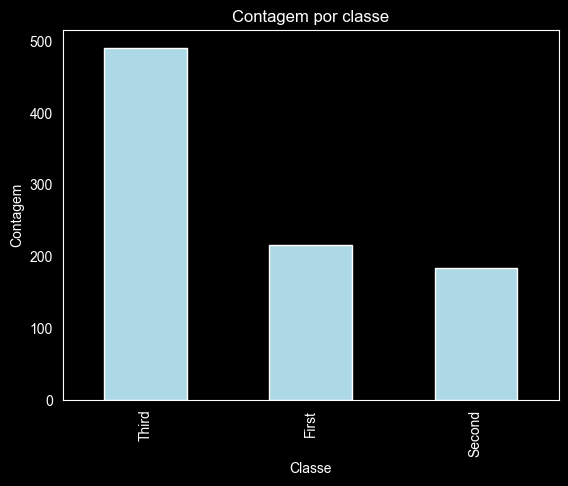

In [34]:
# grafico de barras
df["class"].value_counts().plot(kind="bar", color="lightblue")
plt.title("Contagem por classe")
plt.xlabel("Classe")
plt.ylabel("Contagem")
plt.grid(False)
plt.show()

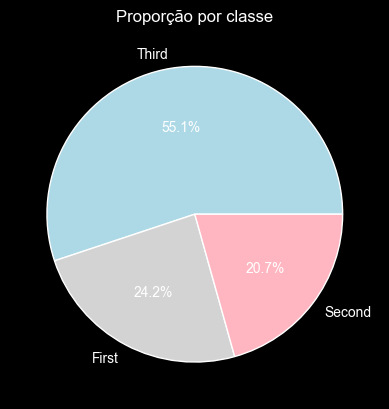

In [35]:
# grafico de pizza
df["class"].value_counts().plot(kind="pie", autopct="%1.1f%%", colors=["lightblue", "lightgray", "lightpink"])
plt.title("Proporção por classe")
plt.ylabel("")  # remover label do eixo y
plt.grid(False)
plt.show()

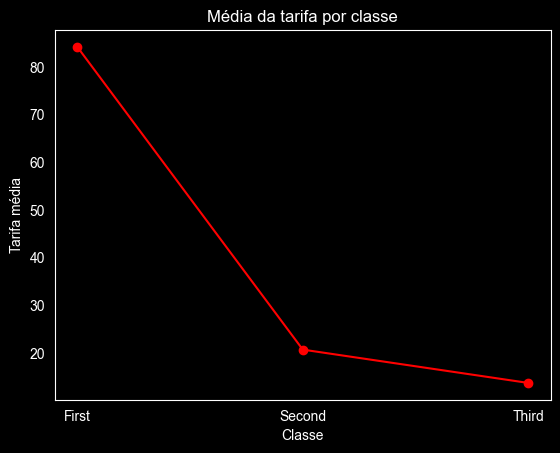

In [36]:
# grafico de linha
df.groupby("class")["fare"].mean().plot(kind="line", marker="o", color="red")
plt.title("Média da tarifa por classe")
plt.xlabel("Classe")
plt.ylabel("Tarifa média")
plt.grid(False)
plt.show()

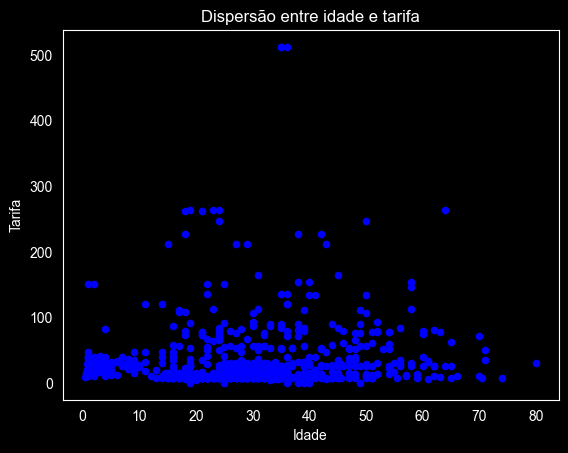

In [37]:
# grafico de dispersão
df.plot(kind="scatter", x="age", y="fare", color="blue")
plt.title("Dispersão entre idade e tarifa")
plt.xlabel("Idade")
plt.ylabel("Tarifa")
plt.grid(False)
plt.show()

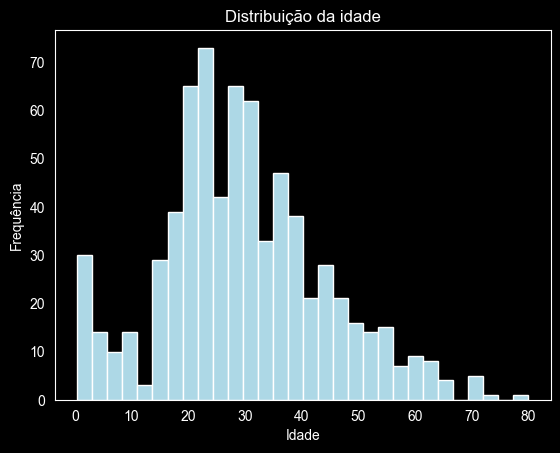

In [38]:
# grafico de histograma
df["age"].plot(kind="hist", bins=30, color="lightblue")
plt.title("Distribuição da idade")
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.grid(False)
plt.show()

ValueError: np.str_('lightbl') is not a valid value for color: supported inputs are (r, g, b) and (r, g, b, a) 0-1 float tuples; '#rrggbb', '#rrggbbaa', '#rgb', '#rgba' strings; named color strings; string reprs of 0-1 floats for grayscale values; 'C0', 'C1', ... strings for colors of the color cycle; and pairs combining one of the above with an alpha value

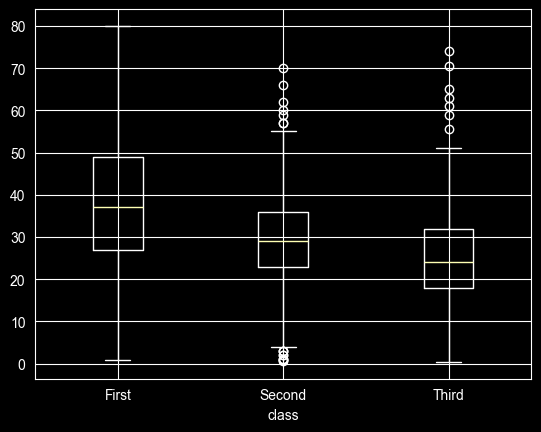

In [39]:
# grafico de boxplot
df.boxplot(column="age", by="class", grid=False, color="lightblue")
plt.title("Boxplot da idade por classe")
plt.suptitle("")  # remover título automático
plt.xlabel("Classe")
plt.ylabel("Idade")
plt.show()

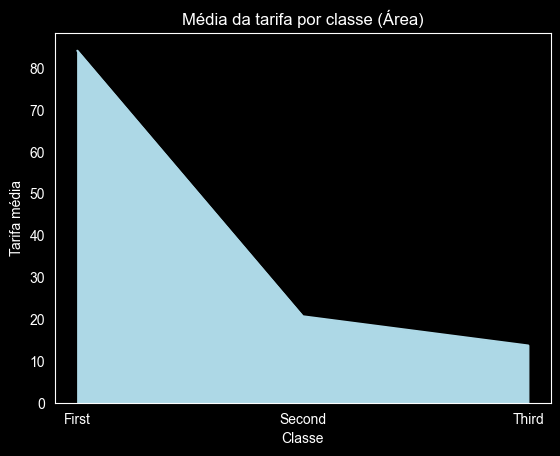

In [40]:
# grafico de area
df.groupby("class")["fare"].mean().plot(kind="area", color="lightblue")
plt.title("Média da tarifa por classe (Área)")
plt.xlabel("Classe")
plt.ylabel("Tarifa média")
plt.grid(False)
plt.show()

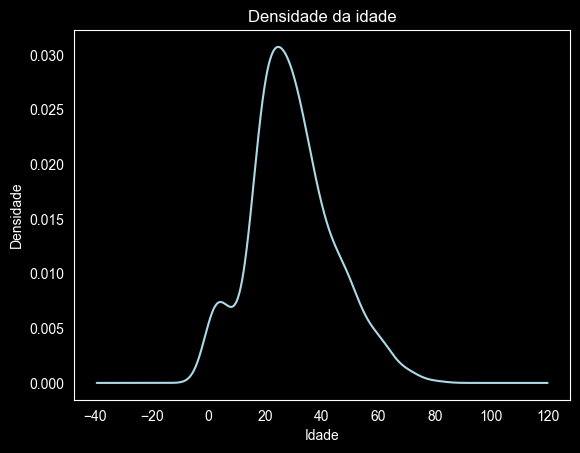

In [41]:
# grafico de densidade
df["age"].plot(kind="kde", color="lightblue")
plt.title("Densidade da idade")
plt.xlabel("Idade")
plt.ylabel("Densidade")
plt.grid(False)
plt.show()

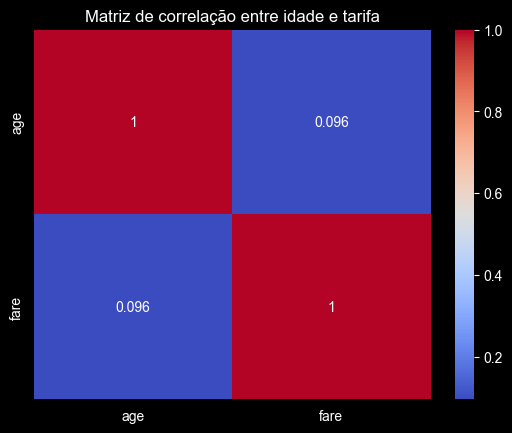

In [42]:
# matriz de corrrelacao direto do pandas
corr = df[["age", "fare"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlação entre idade e tarifa")
plt.show()

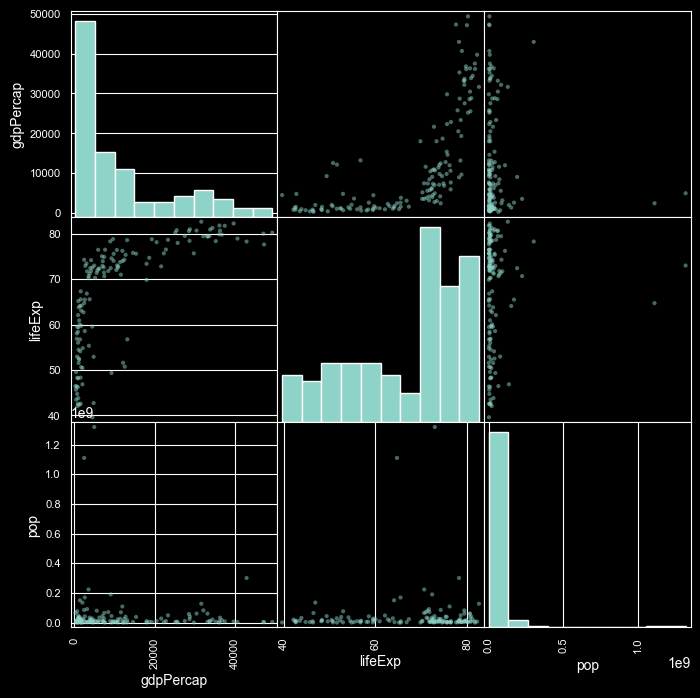

In [47]:
df = px.data.gapminder()

df_2007 = df[df["year"] == 2007][
    ["gdpPercap", "lifeExp", "pop"]
]

pd.plotting.scatter_matrix(df_2007, figsize=(8, 8))
plt.show()